# Проект: Анализ данных об оптовых продажах аудиотехники

**Вам предстоит поработать аналитиком данных в компании «Карпов Саунд», которая занимается оптовой продажей аудиотехники и предлагает широкий ассортимент товаров от ведущих мировых брендов, включающий профессиональные аудиосистемы, домашние кинотеатры, портативные аудиоустройства и прочие аксессуары.** 

«Карпов Саунд» сотрудничает с крупными розничными сетями и специализированными магазинами аудиотехники в России. Клиенты компании регулярно оставляют заявки на закупку товаров в CRM системе, менеджеры связываются с клиентами, обсуждают детали, после чего заказы либо подтверждаются менеджерами, либо по разным причинам отменяются. 

В «Карпов Саунд» трепетно относятся к хранению информации о своих товарах, клиентах и заказах, однако в самый неподходящий момент хранилище данных компании оказалось временно недоступно из-за плановых работ по его оптимизации. Поэтому в рамках этого проекта все данные будут представлены не в самом удобном для анализа виде — в формате резервной выгрузки, разложенной по разным папкам на сервере компании.

Вам необходимо собрать данные из разрозненных источников, проанализировать их и сделать выводы, которые помогут руководству компании принять верные тактические решения.

**Таблицы:**  

1) orders (данные о заказах):  
- order_id — номер заказа  
- product_id — идентификатор товара  
- quantity — количество этого товара в заказе

2) order_status (данные о статусах заказов и клиентах):
- order_id — номер заказа  
- client_id — идентификатор клиента  
- status — статус заказа

3) products (данные о товарах):
- id — идентификатор товара  
- name — имя товара (сначала указан бренд, через запятую модель товара)  
- price — цена единицы товара, в долларах

Каждый заказ имеет статус или подтвержденного (`confirmed`), или отмененного (`canceled`). В одном заказе может быть несколько разных товаров. Если заказ был отменен, а потом создан такой же (тем же клиентом, с теми же товарами, у того же менеджера), в базе останется запись о двух заказах с разными номерами и статусами, поскольку система не позволяет создать заказ с тем же номером.

Сначала вам нужно собрать и предобработать три типа датасетов: `orders.csv`, `order_status.csv`, `products.csv`.

На схеме показано, как связаны таблицы между собой:

![](https://storage.yandexcloud.net/klms-public/production/learning-content/457/4167/37264/104636/497986/er_white.png)

Данные находятся в папке `data` из директории `shared` (`shared` -> `homeworks` -> `python_ds_miniprojects` -> `final_project`). Внутри папки `data` находятся 2 другие папки: `orders` и `products`.

В папке `orders` папки с датами, в которые сделаны записи. В этих папках — папки с именами менеджеров по продажам. Эти папки содержат файлы `orders.csv` и `order_status.csv` (в каждой папке по одной паре файлов). Пример структуры: `data` -> `orders` -> `2024-03-01` -> `Алексей Саксофонов` -> `orders.csv` и `order_status.csv`.

В папке `products` папки с категориями товаров. В этих папках файлы `products.csv` (в каждой папке по одному файлу). Пример структуры: `data` -> `products` -> `AV-процессор` -> `products.csv`.

### Задача 1. Собрать датасет с заказами по папкам

Собрать данные со всех папок в три датафрейма и сохранить их в соответствующие csv файлы: `df_orders.csv`, `df_order_status.csv` и `df_products.csv`.

In [2]:
# импорт библиотек
import pandas as pd
import os

In [3]:
# путь к файлам по заказам #

way = '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/orders'

way

'/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/orders'

In [4]:
# список всех путей #

# Создаём пустой список file_paths, в который будут добавляться пути к файлам.
file_paths = []

# Запускаем цикл for cовместно с методом os.walk() по папке data_folder
# В переменной path находится текущий путь (папка data_folder)
# dirs — список подпапок в текущей папке 
# files — список файлов в них

for path, dirs, files in os.walk(way):
    # Вложенный цикл для перебора файлов в текущей папке
    for file in files:
        # Проверка формата файла — файл должен заканчиваться на '.csv'
        if file.endswith('.csv'):
        # Построение полного пути к файлу с помощью os.path.join(), мы объединяем текущий путь path и имя файла file
            file_path = os.path.join(path, file)
            # Добавляем получившийся путь в список
            file_paths.append(file_path)

file_paths

['/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-07/Надежда Гармошкина/orders.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-07/Надежда Гармошкина/order_status.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-07/Ксения Балалайкина/orders.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-07/Ксения Балалайкина/order_status.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/orders/2024-03-07/Максим Барабанов/orders.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/

In [5]:
# Соберем:
# 1 - df_orders — на основе датасетов orders.csv + добавьте колонку manager с именами менеджеров и колонку date с датами.
# Отсортируйте датафрейм по возрастанию order_id и product_id.
# 2 - df_order_status — на основе датасетов order_status.csv. Отсортируйте датафрейм по возрастанию order_id.

df_orders = pd.DataFrame() 
df_order_status = pd.DataFrame() 

for i in file_paths:
    if i.split('/')[-1] == 'order_status.csv':
        data_os = pd.DataFrame() 
        data_os = pd.read_csv(i)
        df_order_status = pd.concat([df_order_status, data_os])

    if i.split('/')[-1] == 'orders.csv': 
        data_o = pd.DataFrame() 
        data_o = pd.read_csv(i)
        data_o['manager'] = i.split('/')[-2]
        data_o['date'] = i.split('/')[-3]
        df_orders = pd.concat([df_orders, data_o])


In [6]:
df_order_status = df_order_status \
                    .sort_values('order_id') \
                    .reset_index(drop=True)

df_order_status

,order_id,client_id,status
0,ABID-18767701,44,confirmed
1,ACXS-56511429,24,confirmed
2,AEDO-27030558,22,confirmed
3,AFIH-00611801,43,canceled
4,AFUU-55889181,88,confirmed
...,...,...,...
341,ZRCV-04699238,99,confirmed
342,ZREY-28717532,22,confirmed
343,ZUGP-91810341,33,confirmed
344,ZVIS-81883295,14,confirmed


In [7]:
df_orders = df_orders \
                    .sort_values(['order_id', 'product_id']) \
                    .reset_index(drop=True)

df_orders

,order_id,product_id,quantity,manager,date
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11
3,ABID-18767701,557,30,Маргарита Камертонова,2024-03-11
4,ABID-18767701,569,28,Маргарита Камертонова,2024-03-11
...,...,...,...,...,...
4598,ZVTW-19610380,1171,28,Ксения Балалайкина,2024-03-22
4599,ZVTW-19610380,1308,4,Ксения Балалайкина,2024-03-22
4600,ZVTW-19610380,1476,4,Ксения Балалайкина,2024-03-22
4601,ZVTW-19610380,1517,11,Ксения Балалайкина,2024-03-22


In [8]:
# путь к файлам по продуктам #

way_products = '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/products'

way_products

'/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/products'

In [9]:
# список всех путей #

# Создаём пустой список file_paths, в который будут добавляться пути к файлам.
file_paths_products = []

# Запускаем цикл for cовместно с методом os.walk() по папке data_folder
# В переменной path находится текущий путь (папка data_folder)
# dirs — список подпапок в текущей папке 
# files — список файлов в них

for path, dirs, files in os.walk(way_products):
    # Вложенный цикл для перебора файлов в текущей папке
    for file in files:
        # Проверка формата файла — файл должен заканчиваться на '.csv'
        if file.endswith('.csv'):
        # Построение полного пути к файлу с помощью os.path.join(), мы объединяем текущий путь path и имя файла file
            file_path = os.path.join(path, file)
            # Добавляем получившийся путь в список
            file_paths_products.append(file_path)

file_paths_products

['/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/products/Активные колонки/products.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/products/Сабвуфер/products.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/products/Портативная акустика/products.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/products/AV-процессор/products.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/products/Динамический микрофон/products.csv',
 '/mnt/HC_Volume_18315164/home-jupyter/jupyter-ksenija-hmeleva-bry7465/shared/homeworks/python_ds_miniprojects/final_project/data/products/Интеграл

In [10]:
# Соберем - 3 - df_products — на основе датасетов products.csv + добавьте колонку category с категориями товаров.
# Отсортируйте датафрейм по возрастанию id.

df_products = pd.DataFrame() 

for i in file_paths_products:
    data = pd.DataFrame() 
    data = pd.read_csv(i)
    data['category'] = i.split('/')[-2]
    df_products = pd.concat([df_products, data])


In [11]:
df_products = df_products \
                    .sort_values('id') \
                    .reset_index(drop=True)

df_products

,id,name,price,category
0,1,"AKG, D5",180.46,Динамический микрофон
1,2,"AKG, D40",85.80,Динамический микрофон
2,3,"AKG, C414 XLII",935.11,Конденсаторный микрофон
3,4,"AKG, C214",356.02,Конденсаторный микрофон
4,5,"AKG, P120",86.13,Конденсаторный микрофон
...,...,...,...,...
1672,1673,"Yamaha, NS-C210",86.80,Центральный канал
1673,1674,"Yamaha, NS-C210BL",75.98,Центральный канал
1674,1675,"Yamaha, NS-C444",165.50,Центральный канал
1675,1676,"Yamaha, NS-C700",307.89,Центральный канал


In [12]:
# Cохраним их в соответствующие csv файлы: df_orders.csv, df_order_status.csv и df_products.csv.

df_orders.to_csv('df_orders.csv', sep=';', index=False)
df_order_status.to_csv('df_order_status.csv', sep=';', index=False)
df_products.to_csv('df_products.csv', sep=';', index=False)

### Задача 2. Посмотреть на общую динамику заказов и определить дни, которые выбиваются из общей картины

Посчитайте количество заказов в каждый день. **Определите день с наибольшим числом заказов.** Укажите этот день в том формате, в котором он представлен в данных (гггг-мм-дд).

In [16]:
df_orders.head(3)

,order_id,product_id,quantity,manager,date
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11


In [17]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4603 entries, 0 to 4602
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   order_id    4603 non-null   object
 1   product_id  4603 non-null   int64 
 2   quantity    4603 non-null   int64 
 3   manager     4603 non-null   object
 4   date        4603 non-null   object
dtypes: int64(2), object(3)
memory usage: 179.9+ KB


In [18]:
df_orders['date'] = pd.to_datetime(df_orders.date)

In [19]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4603 entries, 0 to 4602
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_id    4603 non-null   object        
 1   product_id  4603 non-null   int64         
 2   quantity    4603 non-null   int64         
 3   manager     4603 non-null   object        
 4   date        4603 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 179.9+ KB


In [20]:
df_orders.date.value_counts()

2024-03-14    437
2024-03-13    339
2024-03-01    302
2024-03-29    241
2024-03-26    231
2024-03-15    225
2024-03-05    222
2024-03-20    222
2024-03-06    221
2024-03-12    203
2024-03-27    203
2024-03-07    201
2024-03-22    191
2024-03-11    185
2024-03-19    172
2024-03-18    159
2024-03-28    155
2024-03-21    152
2024-03-04    143
2024-03-25    129
2024-03-17     43
2024-03-23     42
2024-03-10     35
2024-03-24     33
2024-03-02     30
2024-03-16     26
2024-03-30     20
2024-03-09     18
2024-03-31     10
2024-03-03      8
2024-03-08      5
Name: date, dtype: int64

In [21]:
orders_by_date = df_orders \
                    .groupby('date', as_index = False) \
                    .agg({'order_id': 'count'}) \
                    .rename(columns={'order_id': 'orders'}) \
                    .sort_values('orders',ascending = False) \
                    .reset_index(drop=True)
                 
orders_by_date.head(3)

,date,orders
0,2024-03-14,437
1,2024-03-13,339
2,2024-03-01,302


День с наибольшим числом заказов - 2024-03-14

**Построить график с количеством заказов по дням и определите, заметна ли в данных сезонность.**

- Да, по выходным заказов намного больше, чем в остальные дни  
- Да, по выходным почти нет заказов  
- Да, по понедельникам заказов всегда больше, чем в остальные дни недели  
- Да, по понедельникам заказов всегда меньше, чем в остальные дни недели  
- Нет, в данных сложно обнаружить какие-то закономерности  

In [107]:
orders_by_date['weekday'] = orders_by_date.date.dt.weekday
orders_by_date.head()

,order_id,date,status,weekday
0,ABID-18767701,2024-03-11,confirmed,0
13,ACXS-56511429,2024-03-14,confirmed,3
21,AEDO-27030558,2024-03-22,confirmed,4
34,AFIH-00611801,2024-03-13,canceled,2
45,AFUU-55889181,2024-03-04,confirmed,0


In [23]:
orders_by_date = orders_by_date.sort_values('date')
orders_by_date.head()

,date,orders,weekday
2,2024-03-01,302,4
24,2024-03-02,30,5
29,2024-03-03,8,6
18,2024-03-04,143,0
6,2024-03-05,222,1


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

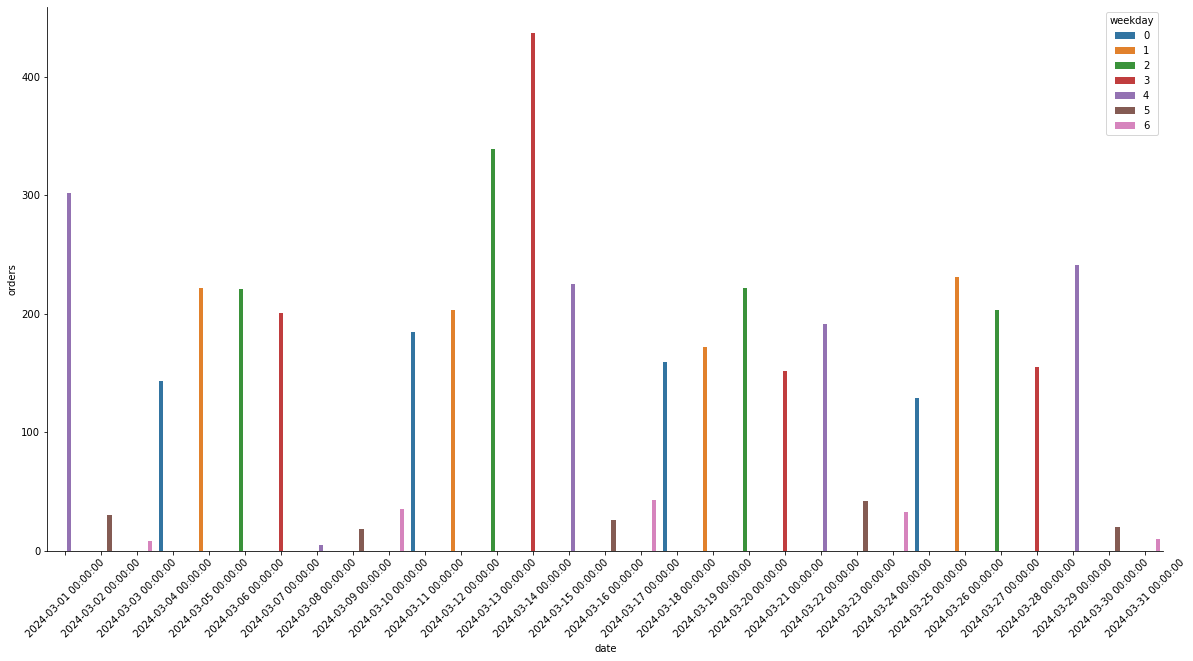

In [25]:
plt.figure(figsize=(20, 10))
ax = sns.barplot(data=orders_by_date, x="date", y="orders", hue="weekday")
ax.set_xticklabels(orders_by_date.date, rotation=45) 
sns.despine()

Да, по выходным почти нет заказов

**Кажется, в данных помимо дня с наибольшим числом заказов есть еще один день, который выбивается из общей картины.** Что это за день:  
- Это воскресенье, в которое было много заказов?  
- Это понедельник, в который было много заказов?  
- Это пятница, в которую было мало заказов?  
- Это праздничный день, в который было мало заказов?

Укажите этот день.

In [26]:
orders_by_date.head(10)

,date,orders,weekday
2,2024-03-01,302,4
24,2024-03-02,30,5
29,2024-03-03,8,6
18,2024-03-04,143,0
6,2024-03-05,222,1
8,2024-03-06,221,2
11,2024-03-07,201,3
30,2024-03-08,5,4
27,2024-03-09,18,5
22,2024-03-10,35,6


Это праздничный день, в который было мало заказов - 2024-03-08

**К вам пришел радостный руководитель отдела продаж и попросил выяснить причину, почему заказы в один из дней резко подскочили, чтобы и дальше увеличивать продажи.**

**Возможно, в день с наибольшим числом заказов (который вы определили на третьем шаге) отдел маркетинга запустил какую-то акцию? Или менеджеры стали активнее предлагать компаниям оформить заказ? Нужно подробнее изучить этот день. Начнем со статусов заказа.**

Добавьте к данным о заказах информацию об их статусах. Общий датафрейм назовите orders_status. В ответе укажите сумму по колонке client_id этого датафрейма.

In [27]:
df_orders.shape

(4603, 5)

In [28]:
df_order_status.head(3)

,order_id,client_id,status
0,ABID-18767701,44,confirmed
1,ACXS-56511429,24,confirmed
2,AEDO-27030558,22,confirmed


In [29]:
orders_status = df_orders.merge(df_order_status, on="order_id", how="left")
orders_status

,order_id,product_id,quantity,manager,date,client_id,status
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed
3,ABID-18767701,557,30,Маргарита Камертонова,2024-03-11,44,confirmed
4,ABID-18767701,569,28,Маргарита Камертонова,2024-03-11,44,confirmed
...,...,...,...,...,...,...,...
4598,ZVTW-19610380,1171,28,Ксения Балалайкина,2024-03-22,44,confirmed
4599,ZVTW-19610380,1308,4,Ксения Балалайкина,2024-03-22,44,confirmed
4600,ZVTW-19610380,1476,4,Ксения Балалайкина,2024-03-22,44,confirmed
4601,ZVTW-19610380,1517,11,Ксения Балалайкина,2024-03-22,44,confirmed


In [30]:
orders_status.client_id.sum()

251232

**Посмотрите на количество и соотношение подтвержденных и отмененных заказов.**

In [31]:
orders_by_status = orders_status[['order_id', 'status']]
orders_by_status = orders_by_status.drop_duplicates()  
orders_by_status

,order_id,status
0,ABID-18767701,confirmed
13,ACXS-56511429,confirmed
21,AEDO-27030558,confirmed
34,AFIH-00611801,canceled
45,AFUU-55889181,confirmed
...,...,...
4540,ZRCV-04699238,confirmed
4558,ZREY-28717532,confirmed
4570,ZUGP-91810341,confirmed
4582,ZVIS-81883295,confirmed


In [32]:
orders_by_status_ = orders_by_status\
                    .groupby('status', as_index = False) \
                    .agg({'order_id': 'count'}) \
                    .rename(columns={'order_id': 'order_count'})

orders_by_status_

,status,order_count
0,canceled,37
1,confirmed,309


In [33]:
order_sum = orders_by_status_.order_count.sum()

orders_by_status_['order_perc'] = round(orders_by_status_['order_count'] / order_sum, 2)

orders_by_status_

,status,order_count,order_perc
0,canceled,37,0.11
1,confirmed,309,0.89


**Посчитайте количество подтвержденных и отмененных заказов на каждую дату. Определите, в какой день не было ни одного подтвержденного заказа.**

In [34]:
orders_status.head()

,order_id,product_id,quantity,manager,date,client_id,status
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed
3,ABID-18767701,557,30,Маргарита Камертонова,2024-03-11,44,confirmed
4,ABID-18767701,569,28,Маргарита Камертонова,2024-03-11,44,confirmed


In [35]:
orders_by_date = orders_status[['order_id', 'date', 'status']]
orders_by_date = orders_by_date.drop_duplicates()  
orders_by_date

,order_id,date,status
0,ABID-18767701,2024-03-11,confirmed
13,ACXS-56511429,2024-03-14,confirmed
21,AEDO-27030558,2024-03-22,confirmed
34,AFIH-00611801,2024-03-13,canceled
45,AFUU-55889181,2024-03-04,confirmed
...,...,...,...
4540,ZRCV-04699238,2024-03-06,confirmed
4558,ZREY-28717532,2024-03-29,confirmed
4570,ZUGP-91810341,2024-03-15,confirmed
4582,ZVIS-81883295,2024-03-27,confirmed


In [36]:
orders_by_date_ = orders_by_date\
                    .groupby(['date', 'status'], as_index = False) \
                    .agg({'order_id': 'count'}) \
                    .rename(columns={'order_id': 'order_count'})

orders_by_date_.head()

,date,status,order_count
0,2024-03-01,canceled,2
1,2024-03-01,confirmed,20
2,2024-03-02,confirmed,2
3,2024-03-03,confirmed,1
4,2024-03-04,confirmed,10


In [37]:
orders_by_date_pivot = orders_by_date_.pivot(index='date', columns='status', values='order_count').reset_index().fillna(0)
orders_by_date_pivot.head(3)

status,date,canceled,confirmed
0,2024-03-01,2.0,20.0
1,2024-03-02,0.0,2.0
2,2024-03-03,0.0,1.0


In [38]:
orders_by_date_pivot[['canceled', 'confirmed']] = orders_by_date_pivot[['canceled', 'confirmed']].astype(int)
orders_by_date_pivot.head(3)

status,date,canceled,confirmed
0,2024-03-01,2,20
1,2024-03-02,0,2
2,2024-03-03,0,1


In [39]:
orders_by_date_pivot.query('confirmed == 0')

status,date,canceled,confirmed
8,2024-03-09,1,0


Не было ни одного подтвержденного заказа в этот день - 2024-03-09

**Постройте график с заказами по дням в разбивке по статусу заказа.** Посмотрим подробнее на день с наибольшим числом заказов (вместе и подтвержденных, и отменных), который мы определили ранее, и на день, предшествующий ему. Какой вывод можно сделать? Выберите один или несколько вариантов:

- В день с наибольшим числом заказов было очень много отмен  
- В день с наибольшим числом заказов было много успешно оформленных заказов  
- В день, предшествующий дню с наибольшим числом заказов, было много отмен  
- В день, предшествующий дню с наибольшим числом заказов, было много успешно оформленных заказов  
- В день, предшествующий дню с наибольшим числом заказов, не было ни одного успешно оформленного заказа  
- В день, предшествующий дню с наибольшим числом заказов, не было ни одного отмененного заказа

In [40]:
orders_by_date_ = orders_by_date_.sort_values('date')
orders_by_date_.head()

,date,status,order_count
0,2024-03-01,canceled,2
1,2024-03-01,confirmed,20
2,2024-03-02,confirmed,2
3,2024-03-03,confirmed,1
4,2024-03-04,confirmed,10


In [41]:
orders_by_date_.dtypes

date           datetime64[ns]
status                 object
order_count             int64
dtype: object

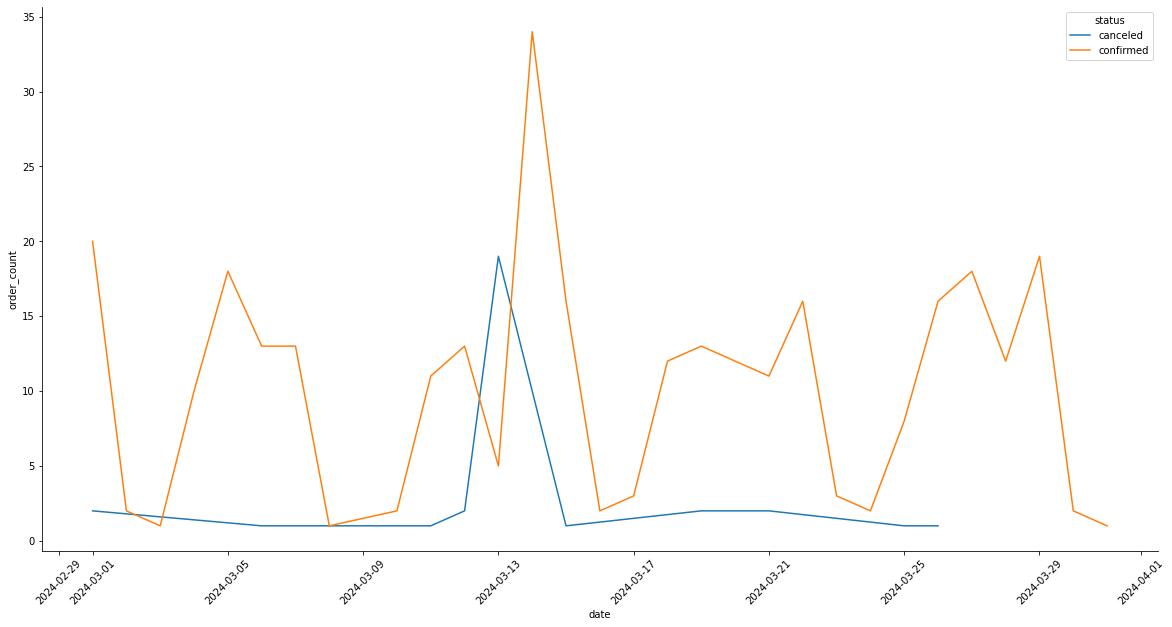

In [42]:
plt.figure(figsize=(20, 10))
ax = sns.lineplot(data=orders_by_date_, x="date", y="order_count", hue="status", sort=True)
plt.xticks(rotation=45)
sns.despine()
plt.show()

In [43]:
orders_by_date_pivot['all_orders'] = orders_by_date_pivot['canceled'] + orders_by_date_pivot['confirmed']
orders_by_date_pivot.head(15)

status,date,canceled,confirmed,all_orders
0,2024-03-01,2,20,22
1,2024-03-02,0,2,2
2,2024-03-03,0,1,1
3,2024-03-04,0,10,10
4,2024-03-05,0,18,18
5,2024-03-06,1,13,14
6,2024-03-07,1,13,14
7,2024-03-08,0,1,1
8,2024-03-09,1,0,1
9,2024-03-10,1,2,3


Вывод:
 - В день с наибольшим числом заказов было много успешно оформленных заказов
 - В день, предшествующий дню с наибольшим числом заказов, было много отмен

**Рассмотрим эти два дня отдельно (день с наибольшим числом заказов, который мы определили ранее, и день, предшествующий ему).** Проанализируйте заказы за эти дни и ответьте, какую из этих гипотез можно назвать наиболее правдоподобной.

- Так сложилось, что один день оказался крайне неудачным для отдела продаж, все клиенты отменили свои заказы. А на следующий день отдел продаж пытался компенсировать отсутствие продаж в предыдущий и перевыполнил дневной план. Почти все заказы не повторяют вчерашние  
- Произошел сбой в работе CRM системы, который не позволил клиентам подтвердить заказ. В результате все созданные в первый день заказы автоматически отменились, поэтому клиентам пришлось оформлять их повторно на следующий день. Почти половина заказов повторяет вчерашние

Как можно определить, что заказ повторяет вчерашний? У заказов будут совпадать сразу несколько параметров: клиент, менеджер, количество уникальных товаров в заказе и общее число товаров в штуках. Но номера заказов будут разными.

Заказ повторяет вчерашний:
 - 1 - Совпадают: клиент, менеджер, количество уникальных товаров в заказе и общее число товаров в штуках.
 - 2 - Номера заказов будут разными.


 - Гипотеза 1 - почти все заказы 14.03 новые
 - Гипотеза 2 - почти 50% заказов 14.03 повторяет заказы 13.03

In [45]:
orders_status

,order_id,product_id,quantity,manager,date,client_id,status
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed
3,ABID-18767701,557,30,Маргарита Камертонова,2024-03-11,44,confirmed
4,ABID-18767701,569,28,Маргарита Камертонова,2024-03-11,44,confirmed
...,...,...,...,...,...,...,...
4598,ZVTW-19610380,1171,28,Ксения Балалайкина,2024-03-22,44,confirmed
4599,ZVTW-19610380,1308,4,Ксения Балалайкина,2024-03-22,44,confirmed
4600,ZVTW-19610380,1476,4,Ксения Балалайкина,2024-03-22,44,confirmed
4601,ZVTW-19610380,1517,11,Ксения Балалайкина,2024-03-22,44,confirmed


1) Отобрать все отмененные заказы 13 марта и для каждого заказа агрегируйте данные: посчитать количество уникальных товаров в нем, сумму единиц всех товаров, а также взять менеджера и клиента (примените к соответствующим колонкам функции max).

In [46]:
df_13m_canceled_ = orders_status.query('date == "2024-03-13" and status == "canceled"')
df_13m_canceled_    

,order_id,product_id,quantity,manager,date,client_id,status
34,AFIH-00611801,17,26,Алексей Саксофонов,2024-03-13,43,canceled
35,AFIH-00611801,240,21,Алексей Саксофонов,2024-03-13,43,canceled
36,AFIH-00611801,468,5,Алексей Саксофонов,2024-03-13,43,canceled
37,AFIH-00611801,505,28,Алексей Саксофонов,2024-03-13,43,canceled
38,AFIH-00611801,511,13,Алексей Саксофонов,2024-03-13,43,canceled
...,...,...,...,...,...,...,...
3962,UUZR-48309816,1469,34,Маргарита Камертонова,2024-03-13,26,canceled
3963,UUZR-48309816,1553,10,Маргарита Камертонова,2024-03-13,26,canceled
3964,UUZR-48309816,1621,7,Маргарита Камертонова,2024-03-13,26,canceled
3965,UUZR-48309816,1644,5,Маргарита Камертонова,2024-03-13,26,canceled


In [47]:
df_13m_canceled = df_13m_canceled_[['order_id', 'product_id', 'quantity', 'manager', 'client_id']] \
                    .groupby('order_id', as_index=False) \
                    .agg({'product_id': 'nunique', 'quantity': 'sum', 'manager': 'max', 'client_id': 'max'}) \
                    .rename(columns={'product_id': 'product_count', 'quantity': 'product_sum'})
    
df_13m_canceled.head(2)

,order_id,product_count,product_sum,manager,client_id
0,AFIH-00611801,11,192,Алексей Саксофонов,43
1,BBFJ-27674101,14,294,Ксения Балалайкина,73


2) Отберем все подтвержденные заказы 14 марта и для каждого заказа агрегируем данные:
посчитать количество уникальных товаров в нем, сумму единиц всех товаров, а также взять менеджера и клиента (примените к соответствующим колонкам функции max).

In [48]:
df_14m_confirmed_ = orders_status.query('date == "2024-03-14" and status == "confirmed"')
df_14m_confirmed_  

,order_id,product_id,quantity,manager,date,client_id,status
13,ACXS-56511429,250,21,Алексей Саксофонов,2024-03-14,24,confirmed
14,ACXS-56511429,477,16,Алексей Саксофонов,2024-03-14,24,confirmed
15,ACXS-56511429,509,16,Алексей Саксофонов,2024-03-14,24,confirmed
16,ACXS-56511429,534,10,Алексей Саксофонов,2024-03-14,24,confirmed
17,ACXS-56511429,646,18,Алексей Саксофонов,2024-03-14,24,confirmed
...,...,...,...,...,...,...,...
4299,YDOT-81201551,762,3,Маргарита Камертонова,2024-03-14,18,confirmed
4300,YDOT-81201551,1099,5,Маргарита Камертонова,2024-03-14,18,confirmed
4301,YDOT-81201551,1334,24,Маргарита Камертонова,2024-03-14,18,confirmed
4302,YDOT-81201551,1592,8,Маргарита Камертонова,2024-03-14,18,confirmed


In [49]:
df_14m_confirmed = df_14m_confirmed_[['order_id', 'product_id', 'quantity', 'manager', 'client_id']] \
                    .groupby('order_id', as_index=False) \
                    .agg({'product_id': 'nunique', 'quantity': 'sum', 'manager': 'max', 'client_id': 'max'}) \
                    .rename(columns={'product_id': 'product_count', 'quantity': 'product_sum'})
    
df_14m_confirmed.head(2)

,order_id,product_count,product_sum,manager,client_id
0,ACXS-56511429,8,177,Алексей Саксофонов,24
1,AUZX-12706022,19,369,Екатерина Тарелкина,83


3) Объединить эти датафреймы с заказами по совпадающим характеристикам: имя менеджера, id клиента, число уникальных товаров в заказе и общее число товаров в штуках. Так у вас получатся те заказы, которые отменили в первый день и оформили заново на следующий.

In [51]:
df_13canceled_14confirmed = df_14m_confirmed \
                            .merge(df_13m_canceled, on=['product_count', 'product_sum', 'manager', 'client_id'], how="inner")

df_13canceled_14confirmed

,order_id_x,product_count,product_sum,manager,client_id,order_id_y
0,AUZX-12706022,19,369,Екатерина Тарелкина,83,RSBH-94158604
1,BCMM-97072924,17,325,Алексей Саксофонов,51,MIGZ-68487439
2,EPBF-14743479,15,207,Виктор Тромбонов,94,JEIF-69283221
3,FDEB-71487438,11,192,Алексей Саксофонов,43,AFIH-00611801
4,FTPV-77865209,16,283,Маргарита Камертонова,26,UUZR-48309816
5,GRCH-73394464,18,399,Алексей Саксофонов,66,KJJS-03491897
6,GYTK-45256974,12,260,Ксения Балалайкина,75,NLSJ-24436750
7,HMXC-87726636,14,262,Маргарита Камертонова,68,QYZK-30462944
8,IECD-18739530,13,205,Виктор Тромбонов,60,CLBQ-63032648
9,IMND-92004620,10,188,Владимир Ударников,38,NENO-68279828


4) Посчитать число строк в датафрейме с заказами, которые отменили в первый день и оформили заново на следующий. Разделите это число на число строк в датафрейме с подтвержденными заказами 14 марта. Так вы узнаете долю заказов, которые повторяют вчерашние.

In [53]:
df_13canceled_14confirmed.shape[0] #кол-во заказов, которые отменили в первый день и оформили заново на следующий.

16

In [54]:
df_14m_confirmed.shape[0] # кол-во подтвержденных заказов 14 марта

34

In [55]:
round(df_13canceled_14confirmed.shape[0] / df_14m_confirmed.shape[0], 2) #доля заказов 14.03, которые повторяют заказы 13.03

0.47

Вывод:
Произошел сбой в работе CRM системы, который не позволил клиентам подтвердить заказ. В результате все созданные в первый день заказы автоматически отменились, поэтому клиентам пришлось оформлять их повторно на следующий день. Почти половина заказов повторяет вчерашние

### Задача 3. Посчитать ключевые метрики, посмотрим на их динамику и составим небольшой отчет

**У вас есть данные за целый месяц, поэтому пора посчитать ключевые метрики этого месяца.** Но вот незадача - в ваших данных цена единицы товара указана в долларах США, потому что закупаете их в долларах, но продаете товары за российские рубли (по тому курсу, который установил Центробанк на дату продажи), а значит и метрики требуется посчитать в рублях. Хорошо, что у вас есть текстовый файл с курсом доллара США на каждую дату. **Откройте файл `usd_rate.txt`, соберите из него датафрейм с 2 колонками: `date` и `currency_rate`. Посчитайте среднее значение курса доллара за месяц.** 

In [56]:
usd_rate = pd.read_csv('usd_rate.txt', header = None)
usd_rate.head(3)

,0,1,2
0,2024-03-01,90.8423,Доллар США
1,2024-03-02,91.3336,Доллар США
2,2024-03-03,91.3336,Доллар США


In [57]:
usd_rate = usd_rate.rename(columns={0:'date', 1:'currency_rate', 2:'currency'})
usd_rate.head(3)

,date,currency_rate,currency
0,2024-03-01,90.8423,Доллар США
1,2024-03-02,91.3336,Доллар США
2,2024-03-03,91.3336,Доллар США


In [58]:
usd_rate = usd_rate[['date','currency_rate']]
usd_rate.head(3)

,date,currency_rate
0,2024-03-01,90.8423
1,2024-03-02,91.3336
2,2024-03-03,91.3336


In [59]:
usd_rate['date'] = pd.to_datetime(usd_rate.date)

In [108]:
#Среднее значение курса доллара за месяц.
usd_rate.currency_rate.mean().round(2)

91.7

**Работу с ключевыми метриками начнем с подсчета общей выручки.**
Данные по товарам в подтвержденных заказах у вас есть в датафрейме `orders_status`, а стоимость одной единицы товара можно взять из датафрейма `df_products`. Объедините эти датафреймы в общий `df_full`, добавьте к ним информацию по курсу доллара на каждую дату. Создайте колонку с выручкой для каждого товара в заказах и посчитайте, **чему равна общая выручка в рублях?** Учитывайте только подтвержденные заказы.

In [61]:
orders_status.head(3)

,order_id,product_id,quantity,manager,date,client_id,status
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed


In [62]:
df_products = df_products.rename(columns={'id':'product_id'})
df_products.head(3)

,product_id,name,price,category
0,1,"AKG, D5",180.46,Динамический микрофон
1,2,"AKG, D40",85.80,Динамический микрофон
2,3,"AKG, C414 XLII",935.11,Конденсаторный микрофон


In [63]:
usd_rate.head(3)

,date,currency_rate
0,2024-03-01,90.8423
1,2024-03-02,91.3336
2,2024-03-03,91.3336


In [64]:
df_full_ = orders_status.merge(df_products, on="product_id", how="left")
df_full_.head(3)

,order_id,product_id,quantity,manager,date,client_id,status,name,price,category
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,"Heco, Stay 300",43.95,Проводные наушники
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed,"JBL, Charge 4",159.13,Беспроводная акустика


In [65]:
df_full = df_full_.merge(usd_rate, on="date", how="left")
df_full.head(3)

,order_id,product_id,quantity,manager,date,client_id,status,name,price,category,currency_rate
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,"Heco, Stay 300",43.95,Проводные наушники,90.7493
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed,"JBL, Charge 4",159.13,Беспроводная акустика,90.7493


In [109]:
# Чему равна общая выручка в рублях?

In [67]:
df_full['revenue_rub'] = df_full.quantity*df_full.price*df_full.currency_rate
df_full.head(3)

,order_id,product_id,quantity,manager,date,client_id,status,name,price,category,currency_rate,revenue_rub
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493,432629.137890
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,"Heco, Stay 300",43.95,Проводные наушники,90.7493,159537.269400
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed,"JBL, Charge 4",159.13,Беспроводная акустика,90.7493,375464.338834


In [68]:
df_confirmed = df_full.query('status == "confirmed"')
df_confirmed.head(3)

,order_id,product_id,quantity,manager,date,client_id,status,name,price,category,currency_rate,revenue_rub
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493,432629.137890
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,"Heco, Stay 300",43.95,Проводные наушники,90.7493,159537.269400
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed,"JBL, Charge 4",159.13,Беспроводная акустика,90.7493,375464.338834


In [110]:
# Общая выручка в рублях
revenue = df_confirmed.revenue_rub.sum().round(2)
revenue

2038231821.56

**Следующая метрика, которую вам нужно посчитать — средний чек в этом месяце (в рублях).** Разделите общую выручку на количество заказов. 

In [70]:
count_orders = df_confirmed.order_id.nunique()
count_orders

309

In [71]:
average_check = revenue/count_orders
average_check.round(2)

6596219.49

**Теперь попробуйте посмотреть на их динамику внутри месяца: посчитайте выручку, средний чек и число заказов — на каждый день.** Посмотрите на графики и выберите верные ответы:

- число заказов и выручка каждый день изменяются в одинаковом направлении (если в этот день число заказов выросло, то и выручка выросла; число заказов упало — в этот же день упала и выручка)  
- число заказов и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день число заказов выросло, то выручка может упасть, и наоборот: число заказов упало — в этот же день выручка выросла)  
- средний чек и выручка каждый день изменяются в одинаковом направлении (если в этот день средний чек вырос, то и выручка выросла; средний чек упал — в этот же день упала и выручка)  
- средний чек и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день средний чек вырос, то выручка может упасть, и наоборот: средний чек упал — в этот же день выручка выросла)  
- в день с наибольшим числом заказов и выручка, и средний чек также показывают максимальное значение  
- в день с наибольшим числом заказов выручка и/или средний чек не показывают максимальное значение  
- с течением времени выручка то увеличивается, то уменьшается  
- с течением времени выручка только увеличивается  
- на протяжении всего месяца средний чек то увеличивается, то уменьшается  
- средний чек на протяжении всего месяца имеет одинаковое значение

In [72]:
df_confirmed_daily = df_confirmed[['date', 'order_id', 'revenue_rub']] \
        .groupby('date', as_index = False)\
        .agg({'order_id': 'nunique','revenue_rub': 'sum'}) \
        .rename(columns={'order_id': 'order_count', 'revenue_rub': 'revenue'})

df_confirmed_daily.head(3)


,date,order_count,revenue
0,2024-03-01,20,1.554118e+08
1,2024-03-02,2,1.197167e+07
2,2024-03-03,1,2.548418e+06


In [73]:
df_confirmed_daily['check'] = df_confirmed_daily.revenue/df_confirmed_daily.order_count
df_confirmed_daily.head(3)

,date,order_count,revenue,check
0,2024-03-01,20,1.554118e+08,7.770588e+06
1,2024-03-02,2,1.197167e+07,5.985834e+06
2,2024-03-03,1,2.548418e+06,2.548418e+06


In [74]:
order_count = df_confirmed_daily[['date', 'order_count']]
order_count.head(2)

,date,order_count
0,2024-03-01,20
1,2024-03-02,2


In [75]:
revenue = df_confirmed_daily[['date', 'revenue']]
revenue.head(2)

,date,revenue
0,2024-03-01,1.554118e+08
1,2024-03-02,1.197167e+07


In [76]:
check = df_confirmed_daily[['date', 'check']]
check.head(2)

,date,check
0,2024-03-01,7.770588e+06
1,2024-03-02,5.985834e+06


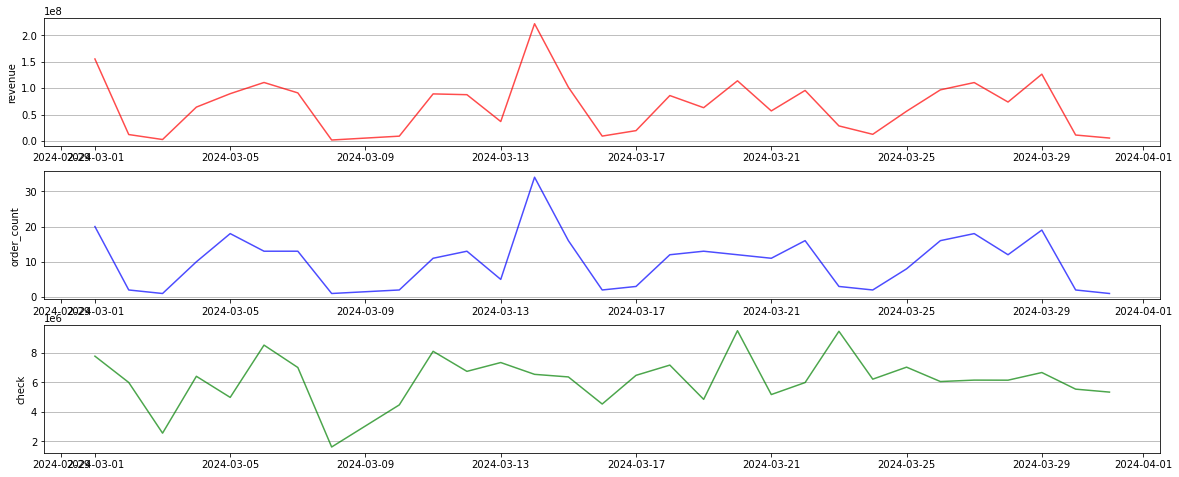

In [77]:
plt.figure(figsize=(20, 8))

# Первый график - выручка
plt.subplot(3, 1, 1)  # 2 строки, 1 столбец, 1-й график
plt.plot(revenue.date, revenue.revenue, color='r', alpha=0.7)
plt.ylabel("revenue")
plt.grid(axis='y')  # Включение сетки по оси y

# Второй график - кол-во заказов
plt.subplot(3, 1, 2)  
plt.plot(order_count.date, order_count.order_count, color='b', alpha=0.7)
plt.ylabel("order_count")
plt.grid(axis='y')

# Третий график - средний чек
plt.subplot(3, 1, 3)  
plt.plot(check.date, check.check, color='g', alpha=0.7)
plt.ylabel("check")
plt.grid(axis='y')

Выводы:

- Число заказов и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день число заказов выросло, то выручка может упасть, и наоборот: число заказов упало — в этот же день выручка выросла)

- Cредний чек и выручка не каждый день изменяются в одинаковом направлении (если в какой-то день средний чек вырос, то выручка может упасть, и наоборот: средний чек упал — в этот же день выручка выросла)

- В день с наибольшим числом заказов выручка и/или средний чек не показывают максимальное значение

- С течением времени выручка то увеличивается, то уменьшается

- На протяжении всего месяца средний чек то увеличивается, то уменьшается

### Задача 4. Проанализировать интерес клиентов к брендам

К вам снова обратился руководитель отдела продаж. Он хочет разобраться, какие бренды востребованы среди клиентов, а какие — нет. **Посчитайте, сколькими брендами интересовались клиенты** (статус заказа здесь не важен, если запись о бренде попала в данные о заказах, значит клиент заказал или хотел заказать товар этого бренда).

In [79]:
df_full.head(3)

,order_id,product_id,quantity,manager,date,client_id,status,name,price,category,currency_rate,revenue_rub
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493,432629.137890
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,"Heco, Stay 300",43.95,Проводные наушники,90.7493,159537.269400
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed,"JBL, Charge 4",159.13,Беспроводная акустика,90.7493,375464.338834


In [80]:
df_full['brand'] = df_full['name'].str.split(',').str[0]
df_full.head(3)

,order_id,product_id,quantity,manager,date,client_id,status,name,price,category,currency_rate,revenue_rub,brand
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493,432629.137890,Beyerdynamic
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,"Heco, Stay 300",43.95,Проводные наушники,90.7493,159537.269400,Heco
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed,"JBL, Charge 4",159.13,Беспроводная акустика,90.7493,375464.338834,JBL


In [81]:
df_full.brand.nunique()

121

Посчитайте, какую выручку принес каждый бренд и в скольких подтвержденных заказах были товары этого бренда. **Определите, какой бренд принес наибольшую выручку.** 

In [82]:
df_report_by_brand = df_full.query('status == "confirmed"')
df_report_by_brand.head(3)


,order_id,product_id,quantity,manager,date,client_id,status,name,price,category,currency_rate,revenue_rub,brand
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493,432629.137890,Beyerdynamic
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,"Heco, Stay 300",43.95,Проводные наушники,90.7493,159537.269400,Heco
2,ABID-18767701,555,26,Маргарита Камертонова,2024-03-11,44,confirmed,"JBL, Charge 4",159.13,Беспроводная акустика,90.7493,375464.338834,JBL


In [83]:
report_by_brand = df_report_by_brand[['brand','order_id','revenue_rub']] \
                        .groupby('brand', as_index = False)\
                        .agg({'order_id': 'nunique','revenue_rub': 'sum'}) \
                        .rename(columns={'order_id': 'orders', 'revenue_rub': 'revenue'}) \
                        .sort_values('revenue', ascending=False)

report_by_brand.head()

,brand,orders,revenue
46,JBL,264,2.665961e+08
43,Heco,229,2.388163e+08
53,Klipsch,205,2.039024e+08
120,Yamaha,218,1.658651e+08
49,KEF,73,1.465101e+08


In [84]:
# Дополнительно: проверьте, именно этот бренд встречается в большем количестве заказов, чем другие бренды?
# Или может его реже заказывают, но на более крупные суммы?

report_by_brand.sort_values('orders', ascending=False).head() # больше заказов этого бренда

,brand,orders,revenue
46,JBL,264,2.665961e+08
43,Heco,229,2.388163e+08
120,Yamaha,218,1.658651e+08
53,Klipsch,205,2.039024e+08
62,Magnat,154,1.141989e+08


У одних брендов большинство товаров востребовано клиентами, а у других — клиенты заказывают только небольшую часть товаров, а остальные зря занимают виртуальную «полку» в перечне товаров, продаваемых вашей компанией. **Вам нужно определить, какие бренды редко попадают в заказы, хотя товаров таких брендов на самом деле много.**

In [85]:
df_confirmed.shape

(4083, 12)

In [86]:
ordered_products = df_confirmed['product_id'].unique().tolist()

In [87]:
df_products['is_in_orders'] = df_products['product_id'].apply(lambda x: 'yes' if x in ordered_products else 'no')
df_products

,product_id,name,price,category,is_in_orders
0,1,"AKG, D5",180.46,Динамический микрофон,no
1,2,"AKG, D40",85.80,Динамический микрофон,yes
2,3,"AKG, C414 XLII",935.11,Конденсаторный микрофон,no
3,4,"AKG, C214",356.02,Конденсаторный микрофон,yes
4,5,"AKG, P120",86.13,Конденсаторный микрофон,no
...,...,...,...,...,...
1672,1673,"Yamaha, NS-C210",86.80,Центральный канал,yes
1673,1674,"Yamaha, NS-C210BL",75.98,Центральный канал,yes
1674,1675,"Yamaha, NS-C444",165.50,Центральный канал,yes
1675,1676,"Yamaha, NS-C700",307.89,Центральный канал,yes


In [88]:
df_products.query('is_in_orders == "yes"').shape #были заказаны в марте 

(1180, 5)

In [89]:
df_products.query('is_in_orders == "no"').shape #не были заказаны в марте 

(497, 5)

In [90]:
df_products.product_id.nunique() #всего товаров 

1677

Примерно треть товаров не была заказана ни разу в этом месяце. Посмотрим на эти данные в разрезе по брендам. **Определите, у каких брендов доля ни разу не заказанных товаров была больше половины от всех продаваемых товаров этого бренда.** Но не берите в расчет бренды, которые представлены маленьким числом товаров (меньше 15), они не захламляют виртуальную «полку».

Отметьте бренды, у которых доля ни разу не заказанных товаров была больше половины от всех продаваемых товаров этого бренда: 
- AKG  
- ASUS	
- Dali  
- Emotiva  
- KEF  
- Marantz  
- Onkyo  
- Pioneer  
- Yaqin

In [91]:
df_products['brand'] = df_products['name'].str.split(',').str[0]
df_products.head(3)

,product_id,name,price,category,is_in_orders,brand
0,1,"AKG, D5",180.46,Динамический микрофон,no,AKG
1,2,"AKG, D40",85.80,Динамический микрофон,yes,AKG
2,3,"AKG, C414 XLII",935.11,Конденсаторный микрофон,no,AKG


In [92]:
df_brand_in_orders = df_products \
                                .groupby(['brand','is_in_orders'], as_index=False) \
                                .agg({'product_id':'count'}) \
                                .rename(columns={'product_id':'count'})
df_brand_in_orders

,brand,is_in_orders,count
0,AKG,no,6
1,AKG,yes,5
2,ART,yes,1
3,ASUS,no,1
4,ASUS,yes,2
...,...,...,...
208,Xiaomi,yes,4
209,YAQIN,no,1
210,Yamaha,no,15
211,Yamaha,yes,91


In [93]:
df_brand_in_orders_pivot = df_brand_in_orders \
                            .pivot(index='brand', columns='is_in_orders', values='count') \
                            .reset_index() \
                            .fillna(0)
df_brand_in_orders_pivot

is_in_orders,brand,no,yes
0,AKG,6.0,5.0
1,ART,0.0,1.0
2,ASUS,1.0,2.0
3,Adam Audio,1.0,0.0
4,Amazon,0.0,4.0
...,...,...,...
141,Wharfedale,7.0,50.0
142,Xiaomi,0.0,4.0
143,YAQIN,1.0,0.0
144,Yamaha,15.0,91.0


In [94]:
df_brand_in_orders_pivot[['no', 'yes']] = df_brand_in_orders_pivot[['no', 'yes']].astype(int)
df_brand_in_orders_pivot

is_in_orders,brand,no,yes
0,AKG,6,5
1,ART,0,1
2,ASUS,1,2
3,Adam Audio,1,0
4,Amazon,0,4
...,...,...,...
141,Wharfedale,7,50
142,Xiaomi,0,4
143,YAQIN,1,0
144,Yamaha,15,91


In [95]:
df_brand_in_orders_pivot['sum'] = df_brand_in_orders_pivot['no'] + df_brand_in_orders_pivot['yes']
df_brand_in_orders_pivot

is_in_orders,brand,no,yes,sum
0,AKG,6,5,11
1,ART,0,1,1
2,ASUS,1,2,3
3,Adam Audio,1,0,1
4,Amazon,0,4,4
...,...,...,...,...
141,Wharfedale,7,50,57
142,Xiaomi,0,4,4
143,YAQIN,1,0,1
144,Yamaha,15,91,106


In [96]:
df_report = df_brand_in_orders_pivot.query('sum >= 15')
df_report

is_in_orders,brand,no,yes,sum
5,Anker,4,11,15
17,Bose,6,15,21
32,Dali,49,18,67
36,Denon,7,34,41
39,Edifier,20,53,73
53,Harman Kardon,19,61,80
54,Heco,6,85,91
57,JBL,7,108,115
60,KEF,54,28,82
64,Klipsch,6,66,72


In [97]:
df_report['no_perc'] = round(df_report['no'] / df_report['sum'], 2)
df_report.sort_values('no_perc', ascending=False).head(4)

/tmp/ipykernel_96/4267714344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_report['no_perc'] = round(df_report['no'] / df_report['sum'], 2)


is_in_orders,brand,no,yes,sum,no_perc
77,Marantz,19,3,22,0.86
32,Dali,49,18,67,0.73
94,Pioneer,70,33,103,0.68
60,KEF,54,28,82,0.66


Бренды, у которых доля ни разу не заказанных товаров была больше половины от всех продаваемых товаров этого бренда

### Задача 5. Составить отчет по продажам менеджеров

Чтобы компания знала, кого из менеджеров отдела продаж премировать, а с кем провести беседу по итогам месяца, **вас попросили сделать отчет по сделкам каждого менеджера**: сколько он оформил подтвержденных заказов и какую выручку они принесли. Но в абсолютных числах вклад каждого сотрудника может быть непонятен. **Поэтому посчитайте значения в процентах: какой % выручки от общей выручки за месяц приходится на каждого менеджера, и какой % заказов от общего числа заказов.** Посчитайте данные и визуализируйте результат, чтобы принимать решение о поощрении или проведении беседы с менеджерами было удобнее. Выберите верные ответы:

- лучшим менеджером по % выручки стала Маргарита Камертонова  
- лучшим менеджером по % заказов стала Маргарита Камертонова  
- первая пятерка менеджеров по % выручки сильно ушла вперед от всех остальных (явно виден большой разрыв между каждым из первой пятерки и каждым из всех остальных менеджеров)  
- в этом месяце нельзя выделить явную пятерку лидеров по % выручки, которые сильно оторвались от остальных  
- лидер по % заказов реализовал более 16% заказов  
- лидер по % заказов реализовал менее 16% заказов  
- наихудшие показатели у Сергея Контрабасова  
- наихудшие показатели у Аркадия Октавина  
- Антон Скрипкин принес в 3 раза меньше выручки, чем Виктор Тромбонов  
- Антон Скрипкин реализовал почти в 3 раза меньше заказов, чем Анастасия Дудкина

In [99]:
df_confirmed.head(2)

,order_id,product_id,quantity,manager,date,client_id,status,name,price,category,currency_rate,revenue_rub
0,ABID-18767701,72,30,Маргарита Камертонова,2024-03-11,44,confirmed,"Beyerdynamic, DT 990 PRO",158.91,Проводные наушники,90.7493,432629.13789
1,ABID-18767701,509,40,Маргарита Камертонова,2024-03-11,44,confirmed,"Heco, Stay 300",43.95,Проводные наушники,90.7493,159537.26940


In [100]:
df_report_by_manager = df_confirmed \
                        .groupby('manager', as_index=False) \
                        .agg({'order_id':'nunique', 'revenue_rub':'sum'}) \
                        .rename(columns={'order_id':'orders'})
df_report_by_manager

,manager,orders,revenue_rub
0,Алексей Саксофонов,27,1.953435e+08
1,Анастасия Дудкина,20,1.234504e+08
2,Антон Скрипкин,7,5.150268e+07
3,Аркадий Октавин,5,2.973678e+07
4,Виктор Тромбонов,50,3.188999e+08
5,Владимир Ударников,31,2.084865e+08
6,Екатерина Тарелкина,28,1.781576e+08
7,Ксения Балалайкина,27,1.817621e+08
8,Максим Барабанов,40,2.401478e+08
9,Маргарита Камертонова,48,3.473886e+08


In [101]:
orders_sum = df_report_by_manager.orders.sum()
orders_sum

309

In [102]:
revenue_sum = df_report_by_manager.revenue_rub.sum().round(2)
revenue_sum

2038231821.56

In [103]:
df_report_by_manager['orders_perc'] = round((df_report_by_manager['orders']/orders_sum)*100,1)
df_report_by_manager['revenue_perc'] = round((df_report_by_manager['revenue_rub']/revenue_sum)*100,1)
df_report_by_manager

,manager,orders,revenue_rub,orders_perc,revenue_perc
0,Алексей Саксофонов,27,1.953435e+08,8.7,9.6
1,Анастасия Дудкина,20,1.234504e+08,6.5,6.1
2,Антон Скрипкин,7,5.150268e+07,2.3,2.5
3,Аркадий Октавин,5,2.973678e+07,1.6,1.5
4,Виктор Тромбонов,50,3.188999e+08,16.2,15.6
5,Владимир Ударников,31,2.084865e+08,10.0,10.2
6,Екатерина Тарелкина,28,1.781576e+08,9.1,8.7
7,Ксения Балалайкина,27,1.817621e+08,8.7,8.9
8,Максим Барабанов,40,2.401478e+08,12.9,11.8
9,Маргарита Камертонова,48,3.473886e+08,15.5,17.0


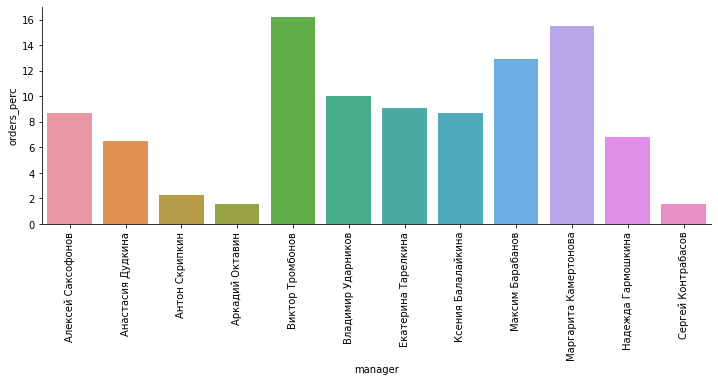

In [104]:
plt.figure(figsize=(12, 4))
sns.barplot(data=df_report_by_manager, x="manager", y="orders_perc")
plt.xticks(rotation=90)
sns.despine()

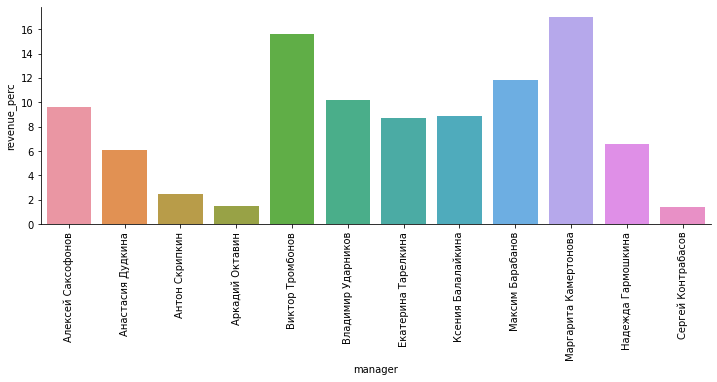

In [105]:
plt.figure(figsize=(12, 4))
sns.barplot(data=df_report_by_manager, x="manager", y="revenue_perc")
plt.xticks(rotation=90)
sns.despine()

In [106]:
df_report_by_manager.sort_values('revenue_perc', ascending=False)

,manager,orders,revenue_rub,orders_perc,revenue_perc
9,Маргарита Камертонова,48,3.473886e+08,15.5,17.0
4,Виктор Тромбонов,50,3.188999e+08,16.2,15.6
8,Максим Барабанов,40,2.401478e+08,12.9,11.8
5,Владимир Ударников,31,2.084865e+08,10.0,10.2
0,Алексей Саксофонов,27,1.953435e+08,8.7,9.6
7,Ксения Балалайкина,27,1.817621e+08,8.7,8.9
6,Екатерина Тарелкина,28,1.781576e+08,9.1,8.7
10,Надежда Гармошкина,21,1.347836e+08,6.8,6.6
1,Анастасия Дудкина,20,1.234504e+08,6.5,6.1
2,Антон Скрипкин,7,5.150268e+07,2.3,2.5


Выводы:
 - лучшим менеджером по % выручки стала Маргарита Камертонова
 - в этом месяце нельзя выделить явную пятерку лидеров по % выручки, которые сильно оторвались от остальных
 - лидер по % заказов реализовал более 16% заказов
 - наихудшие показатели у Сергея Контрабасова
 - Антон Скрипкин реализовал почти в 3 раза меньше заказов, чем Анастасия Дудкина

## Итоги

В этом проекте мы проанализировали продажи музыкальных товаров:
 - собрали данные,
 - посчитали ключевые метрики в динамике;
 - определили дни, которые выбиваются из общей картины, и выяснили причину этого;
 - нашли наиболее прибыльные бренды и те, которые зря занимают место на виртуальной «полке». 